# 4.3 — Lesion Segmentation: Attention U-Net

## What This Notebook Does
This notebook trains a **U-Net (ResNet34 encoder)** to simultaneously segment **5 retinal lesion types**:

| Channel | Code | Lesion Type | Clinical Meaning |
|---------|------|-------------|------------------|
| 0 | **MA** | Microaneurysms | Earliest sign of DR — tiny balloon-like swellings in blood vessels |
| 1 | **HE** | Hemorrhages | Blood leaking from damaged retinal vessels |
| 2 | **EX** | Hard Exudates | Yellow lipid deposits, indicate macular edema |
| 3 | **OD** | Optic Disc | Anatomical landmark — used as spatial reference |
| 4 | **CW** | Cotton Wool Spots | White patches from nerve fiber infarcts, severe ischemia |

### Key Difference from Vessel Segmentation
- **Vessel models** output `(B, 1, H, W)` — single binary mask
- **Lesion models** output `(B, 5, H, W)` — five independent binary masks

Each pixel can belong to **multiple lesion types** simultaneously (multi-label).

### Architecture: U-Net
U-Net uses an **encoder-decoder** structure with **skip connections**:
- **Encoder** (ResNet34, pretrained on ImageNet): extracts features at multiple scales
- **Decoder**: upsamples features back to full resolution
- **Skip connections**: connect encoder to decoder at each scale, preserving spatial detail

The final layer outputs 5 channels instead of 1, one for each lesion type.

## 1. Setup & Installation

In [1]:
# Install required libraries (run once per Colab session)
!pip install -q albumentations segmentation-models-pytorch timm

In [2]:
# Clone the repository (skip if already cloned)
import os


## 2. Reproducibility — Seed Everything

**Why this matters:**  
Without seeding, re-running the same notebook gives slightly different results because:
- Random weight initialization varies
- Random data augmentation varies
- GPU floating-point operations are non-deterministic by default

`seed_everything(42)` locks ALL random sources so results are **identical every run**.

## 3. Imports & Configuration

In [3]:
import json
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
"""
Retinal DR Detection — Lesion Segmentation Dataset
=====================================================
Multi-label dataset for simultaneous segmentation of 5 lesion types.

Key difference from VesselDataset (src/dataset.py):
  - Vessel segmentation = SINGLE binary mask  → model outputs (B, 1, H, W)
  - Lesion segmentation = FIVE  binary masks  → model outputs (B, 5, H, W)

Each image produces a stacked mask tensor of shape (5, H, W) where:
  Channel 0 → MA  (Microaneurysms)        — earliest sign of DR
  Channel 1 → HE  (Hemorrhages)           — blood leaking from vessels
  Channel 2 → EX  (Hard Exudates)         — lipid deposits, sign of macular edema
  Channel 3 → OD  (Optic Disc)            — anatomical landmark for spatial reference
  Channel 4 → CW  (Cotton Wool spots)     — nerve fiber infarcts, severe ischemia

Albumentations automatically applies the SAME spatial transform (flip,
rotate, distort) to ALL mask channels, ensuring geometric consistency.
"""

import os
import cv2
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2


# ============================================================
# The 5 lesion types — this is the SINGLE source of truth
# ============================================================
LESION_TYPES = ['MA', 'HE', 'EX', 'OD', 'CW']
NUM_LESION_CLASSES = len(LESION_TYPES)


class LesionDataset(Dataset):
    """
    Multi-label retinal lesion segmentation dataset.

    For each fundus image it loads 5 binary masks (one per lesion type)
    and stacks them into a single (5, H, W) tensor.  If a mask file
    doesn't exist for a particular lesion type, a zero-mask (= "no
    lesion present") is used — this is the correct ground truth.

    Args:
        csv_file     : Path to CSV with 'img_id' and 'img_path' columns.
        base_dir     : Root directory of the processed dataset
                       (e.g. 'dataset_stage1_segmentation_processed').
        transform    : Albumentations Compose pipeline (from get_*_transforms).
        lesion_mask_dir : Sub-folder containing per-type mask folders
                         (default 'lesion_masks').
        lesion_types : Which lesion types to load (default LESION_TYPES).
    """

    def __init__(self, csv_file, base_dir, transform=None,
                 lesion_mask_dir='lesion_masks',
                 lesion_types=None):
        self.df = pd.read_csv(csv_file)

        # Keep only rows that have at least one lesion mask
        if 'has_lesion' in self.df.columns:
            self.df = self.df[self.df['has_lesion'] == True].reset_index(drop=True)

        self.base_dir = base_dir
        self.lesion_mask_dir = lesion_mask_dir
        self.transform = transform
        self.lesion_types = lesion_types or LESION_TYPES

    def __len__(self):
        return len(self.df)

    # ----------------------------------------------------------
    def _load_single_mask(self, img_id, lesion_type):
        """
        Attempt to load one lesion mask from disk.

        Path convention (set during preprocessing):
            {base_dir}/lesion_masks/{lesion_type}/{img_id}
            e.g.  dataset_processed/lesion_masks/MA/IDRID_train_IDRiD_01.png

        Returns:
            np.ndarray (H, W) float32 with values 0.0 / 1.0, or None.
        """
        mask_path = os.path.join(
            self.base_dir, self.lesion_mask_dir, lesion_type, img_id
        )
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                return (mask > 127).astype(np.float32)
        return None

    # ----------------------------------------------------------
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['img_id']               # e.g. "IDRID_train_IDRiD_01.png"

        # ---- 1. Load RGB image ----
        img_path = os.path.join(self.base_dir, row['img_path'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        # ---- 2. Load & stack all 5 lesion masks → (H, W, 5) ----
        #   Albumentations treats a 3-D mask array as a multi-channel
        #   mask and applies the same geometric transform to every channel.
        mask_stack = np.zeros((h, w, len(self.lesion_types)), dtype=np.float32)
        for i, lt in enumerate(self.lesion_types):
            m = self._load_single_mask(img_id, lt)
            if m is not None:
                mask_stack[:, :, i] = m

        # ---- 3. Apply augmentations ----
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask_stack)
            image = augmented['image']       # Tensor (3, H, W) after ToTensorV2
            mask_stack = augmented['mask']    # Tensor (5, H, W) after ToTensorV2

        # ---- 4. Ensure correct tensor format: (C, H, W) ----
        #   ToTensorV2 in newer albumentations does NOT auto-transpose
        #   multi-channel masks, so we handle it explicitly.
        if isinstance(mask_stack, np.ndarray):
            # No transform applied — convert manually
            mask_tensor = torch.from_numpy(
                mask_stack.transpose(2, 0, 1)  # (H, W, 5) → (5, H, W)
            ).float()
        elif isinstance(mask_stack, torch.Tensor):
            if mask_stack.dim() == 3 and mask_stack.shape[-1] == len(self.lesion_types):
                # Shape is (H, W, 5) — need to permute to (5, H, W)
                mask_tensor = mask_stack.permute(2, 0, 1).float()
            else:
                mask_tensor = mask_stack.float()
        else:
            mask_tensor = torch.as_tensor(mask_stack).float()

        return image, mask_tensor


# ============================================================
# Augmentation Pipelines (same as vessel, reused here)
# ============================================================

def get_train_transforms(img_size=512):
    """
    Training augmentation pipeline.

    Geometric transforms handle fundus image variability:
      - Different camera angles       → flips & rotations
      - Different fields of view      → scale variations
      - Patient movement              → shift & distortion

    Color transforms handle:
      - Different fundus camera brands → brightness/contrast variation
      - Different illumination         → hue/saturation shifts
    """
    return A.Compose([
        A.Resize(img_size, img_size),

        # === Geometric Augmentations ===
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(
            translate_percent={'x': (-0.0625, 0.0625), 'y': (-0.0625, 0.0625)},
            scale=(0.9, 1.1),
            rotate=(-45, 45),
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5
        ),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.2),

        # === Color / Illumination Augmentations ===
        A.ColorJitter(brightness=0.2, contrast=0.2,
                      saturation=0.2, hue=0.1, p=0.4),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.GaussNoise(std_range=(0.02, 0.05), p=0.2),

        # === Normalization (ImageNet stats for pretrained backbones) ===
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


def get_val_transforms(img_size=512):
    """
    Validation/Test transform — NO augmentation, only resize + normalize.
    We must evaluate on clean, unaugmented images for fair comparison.
    """
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])



In [5]:
"""
Retinal DR Detection — Lesion Training Utilities
==================================================
Multi-label loss function for 5-channel lesion segmentation.

Key insight: OD is huge (~5% of pixels), MA is tiny (~0.003% of pixels).
If we weight all channels equally, the model just learns OD and ignores
everything else. Solution: give HIGHER weight to rare/tiny lesion types.
"""

import torch
import torch.nn as nn


class MultiLabelDiceBCELoss(nn.Module):
    """
    Weighted Dice + BCE loss for multi-label segmentation.

    WHAT CHANGED from the original version:
      - Each lesion channel now has its own weight in the loss
      - Tiny lesions (MA, HE, CW) get HIGHER weights
      - Large lesions (OD) get LOWER weights
      - This forces the model to spend more effort learning tiny structures

    The weights are based on how rare each lesion type is:
      MA  = 3.0  (tiny dots, hardest to detect → highest weight)
      HE  = 2.5  (small blobs, hard)
      EX  = 1.5  (medium patches)
      OD  = 0.5  (giant circle, easy → lowest weight)
      CW  = 2.5  (small patches, hard)

    Args:
        dice_weight    : Weight for the Dice component (default 0.5)
        bce_weight     : Weight for the BCE component  (default 0.5)
        smooth         : Smoothing factor to avoid division by zero
        channel_weights: Per-channel importance weights [MA, HE, EX, OD, CW]
    """

    def __init__(self, dice_weight=0.5, bce_weight=0.5, smooth=1e-6,
                 channel_weights=None):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

        # Default weights: penalise ignoring tiny lesions
        if channel_weights is None:
            #                  MA   HE   EX   OD   CW
            channel_weights = [3.0, 2.5, 1.5, 0.5, 2.5]
        self.register_buffer(
            'channel_weights',
            torch.tensor(channel_weights, dtype=torch.float32)
        )

    def _dice_loss_per_channel(self, pred_logits, targets):
        """Compute WEIGHTED Dice loss for each channel separately."""
        pred = torch.sigmoid(pred_logits)               # (B, C, H, W)
        B, C, H, W = pred.shape

        # Reshape to (C, B*H*W) so each channel is independent
        pred_flat = pred.permute(1, 0, 2, 3).reshape(C, -1)
        tgt_flat  = targets.permute(1, 0, 2, 3).reshape(C, -1)

        intersection = (pred_flat * tgt_flat).sum(dim=1)      # (C,)
        union = pred_flat.sum(dim=1) + tgt_flat.sum(dim=1)    # (C,)

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1.0 - dice   # (C,)

        # Apply channel weights: MA loss × 3.0, OD loss × 0.5, etc.
        w = self.channel_weights.to(dice_loss.device)
        weighted = (dice_loss * w).sum() / w.sum()
        return weighted

    def _bce_loss_per_channel(self, pred_logits, targets):
        """Compute WEIGHTED BCE loss per channel."""
        B, C, H, W = pred_logits.shape
        bce_all = self.bce(pred_logits, targets)  # (B, C, H, W)

        # Average over batch and spatial dims → per-channel loss (C,)
        per_channel = bce_all.mean(dim=(0, 2, 3))  # (C,)

        # Apply channel weights
        w = self.channel_weights.to(per_channel.device)
        weighted = (per_channel * w).sum() / w.sum()
        return weighted

    def forward(self, pred_logits, targets):
        """
        Args:
            pred_logits : (B, C, H, W) raw model output BEFORE sigmoid
            targets     : (B, C, H, W) binary ground truth
        Returns:
            Scalar loss value
        """
        dice = self._dice_loss_per_channel(pred_logits, targets)
        bce  = self._bce_loss_per_channel(pred_logits, targets)
        return self.dice_weight * dice + self.bce_weight * bce


In [6]:
"""
Retinal DR Detection — Lesion Evaluation Metrics
==================================================
Per-channel and overall metrics for multi-label lesion segmentation.

For each of the 5 lesion types we compute:
  - Dice Coefficient  (primary metric)
  - IoU / Jaccard Index
  - Sensitivity (Recall)  — "did we find all lesion pixels?"
  - Specificity            — "did we avoid false alarms?"
  - Precision (PPV)

Then we report both per-type scores AND macro-averaged scores.
"""

import numpy as np
import torch
from sklearn.metrics import roc_auc_score, average_precision_score




def evaluate_multilabel_batch(pred_logits, targets, threshold=0.5):
    """
    Compute metrics for a batch of multi-label predictions.

    Args:
        pred_logits : (B, C, H, W)  raw model output BEFORE sigmoid
        targets     : (B, C, H, W)  binary ground truth
        threshold   : Binarization threshold for sigmoid output

    Returns:
        dict with per-channel and mean metrics
        Example: {'dice_MA': 0.72, ..., 'dice_mean': 0.68, ...}
    """
    smooth = 1e-6
    with torch.no_grad():
        pred_probs  = torch.sigmoid(pred_logits)
        pred_binary = (pred_probs > threshold).float()

        B, C, H, W = pred_binary.shape
        metrics = {}

        for ch in range(C):
            p = pred_binary[:, ch, :, :].contiguous().view(-1)
            t = targets[:, ch, :, :].contiguous().view(-1)

            tp = (p * t).sum()
            fp = (p * (1 - t)).sum()
            fn = ((1 - p) * t).sum()
            tn = ((1 - p) * (1 - t)).sum()

            dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
            iou  = (tp + smooth) / (tp + fp + fn + smooth)
            sens = (tp + smooth) / (tp + fn + smooth)
            spec = (tn + smooth) / (tn + fp + smooth)
            prec = (tp + smooth) / (tp + fp + smooth)

            lt = LESION_TYPES[ch] if ch < len(LESION_TYPES) else f'ch{ch}'
            metrics[f'dice_{lt}'] = dice.item()
            metrics[f'iou_{lt}']  = iou.item()
            metrics[f'sens_{lt}'] = sens.item()
            metrics[f'spec_{lt}'] = spec.item()
            metrics[f'prec_{lt}'] = prec.item()

        # Macro averages
        for m in ['dice', 'iou', 'sens', 'spec', 'prec']:
            vals = [metrics[f'{m}_{LESION_TYPES[c]}'] for c in range(C)]
            metrics[f'{m}_mean'] = np.mean(vals)

    return metrics


def evaluate_multilabel_full(pred_probs_all, targets_all,
                             num_classes=None, threshold=0.5):
    """
    Compute ALL metrics on the full test set (after collecting
    all predictions across batches).

    Args:
        pred_probs_all : np.array (N, C, H, W)  sigmoid probabilities
        targets_all    : np.array (N, C, H, W)  binary ground truth
        num_classes    : Number of channels (default: len(LESION_TYPES))

    Returns:
        dict with per-channel AND macro-averaged metrics including AUC
    """
    smooth = 1e-6
    if num_classes is None:
        num_classes = len(LESION_TYPES)

    pred_binary = (pred_probs_all > threshold).astype(np.float32)
    results = {}

    for ch in range(num_classes):
        p_flat = pred_binary[:, ch, :, :].ravel()
        t_flat = targets_all[:, ch, :, :].ravel()
        prob_flat = pred_probs_all[:, ch, :, :].ravel()

        tp = (p_flat * t_flat).sum()
        fp = (p_flat * (1 - t_flat)).sum()
        fn = ((1 - p_flat) * t_flat).sum()
        tn = ((1 - p_flat) * (1 - t_flat)).sum()

        dice = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
        iou  = (tp + smooth) / (tp + fp + fn + smooth)
        sens = (tp + smooth) / (tp + fn + smooth)
        spec = (tn + smooth) / (tn + fp + smooth)
        prec = (tp + smooth) / (tp + fp + smooth)
        acc  = (tp + tn) / (tp + tn + fp + fn + smooth)

        # AUC metrics (may fail if all labels are the same)
        try:
            auc_roc = roc_auc_score(t_flat, prob_flat)
        except ValueError:
            auc_roc = 0.0
        try:
            auc_pr = average_precision_score(t_flat, prob_flat)
        except ValueError:
            auc_pr = 0.0

        lt = LESION_TYPES[ch] if ch < len(LESION_TYPES) else f'ch{ch}'
        results[f'dice_{lt}']    = float(dice)
        results[f'iou_{lt}']     = float(iou)
        results[f'sens_{lt}']    = float(sens)
        results[f'spec_{lt}']    = float(spec)
        results[f'prec_{lt}']    = float(prec)
        results[f'acc_{lt}']     = float(acc)
        results[f'auc_roc_{lt}'] = float(auc_roc)
        results[f'auc_pr_{lt}']  = float(auc_pr)

    # Macro averages
    for m in ['dice', 'iou', 'sens', 'spec', 'prec', 'acc',
              'auc_roc', 'auc_pr']:
        vals = [results[f'{m}_{LESION_TYPES[c]}'] for c in range(num_classes)]
        results[f'{m}_mean'] = float(np.mean(vals))

    return results


In [7]:
import zipfile


zip_path = "DR_dataset_processed.zip"     # Change this to your actual zip file name
extract_dir = "dataset"           # Where to extract your files

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [8]:
# ===== CONFIGURATION =====
# These hyperparameters are IDENTICAL across all CNN-based lesion models
# to ensure a fair comparison.

CFG = {
    'model_name'    : 'Attention_UNet_ResNet34',
    'img_size'      : 512,
    'batch_size'    : 2,
    'num_epochs'    : 80,
    'learning_rate' : 1e-4,
    'weight_decay'  : 1e-4,
    'patience'      : 15,       # Early stopping patience
    'dice_weight'   : 0.5,
    'bce_weight'    : 0.5,
    'threshold'     : 0.3,
    'num_workers'   : 2,
    'use_amp'       : True,     # Mixed precision for faster training
    'out_channels'  : NUM_LESION_CLASSES,  # 5 lesion types
    'seed'          : 42,
}

# Paths — adjust if your dataset is elsewhere
DATA_DIR   = 'dataset'
ALL_CSV    = os.path.join(DATA_DIR, 'all_images.csv')
SAVE_DIR   = f'lesion_results/{CFG["model_name"]}'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'Model: {CFG["model_name"]}')
print(f'Lesion types: {LESION_TYPES}  ({CFG["out_channels"]} channels)')
print(f'Output dir: {SAVE_DIR}')

Model: Attention_UNet_ResNet34
Lesion types: ['MA', 'HE', 'EX', 'OD', 'CW']  (5 channels)
Output dir: lesion_results/Attention_UNet_ResNet34


## 4. Data Preparation

### Creating Lesion-Specific Splits
The preprocessing notebook created `all_images.csv` with ALL images.  
We filter for images that have **at least one lesion mask** (`has_lesion == True`),  
then split 70% / 15% / 15% into train/val/test.

In [9]:
# Load master CSV and filter for lesion images
df_all = pd.read_csv(ALL_CSV)
df_lesion = df_all[df_all['has_lesion'] == True].reset_index(drop=True)
print(f'Total images with lesion masks: {len(df_lesion)}')

# Split: 70% train, 15% val, 15% test
train_df, rem_df = train_test_split(df_lesion, test_size=0.30, random_state=CFG['seed'])
val_df, test_df  = train_test_split(rem_df,    test_size=0.50, random_state=CFG['seed'])

# Save splits so every model uses exactly the same data
LESION_TRAIN_CSV = os.path.join(DATA_DIR, 'lesion_train_split.csv')
LESION_VAL_CSV   = os.path.join(DATA_DIR, 'lesion_val_split.csv')
LESION_TEST_CSV  = os.path.join(DATA_DIR, 'lesion_test_split.csv')

train_df.to_csv(LESION_TRAIN_CSV, index=False)
val_df.to_csv(LESION_VAL_CSV, index=False)
test_df.to_csv(LESION_TEST_CSV, index=False)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print('✅ Lesion split CSVs saved')

Total images with lesion masks: 279
Train: 195 | Val: 42 | Test: 42
✅ Lesion split CSVs saved


In [10]:
# Create datasets and dataloaders
train_dataset = LesionDataset(LESION_TRAIN_CSV, DATA_DIR, transform=get_train_transforms(CFG['img_size']))
val_dataset   = LesionDataset(LESION_VAL_CSV,   DATA_DIR, transform=get_val_transforms(CFG['img_size']))
test_dataset  = LesionDataset(LESION_TEST_CSV,  DATA_DIR, transform=get_val_transforms(CFG['img_size']))

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True,  num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

# Quick sanity check
imgs, masks = next(iter(train_loader))
print(f'Image batch shape: {imgs.shape}')   # Expected: (B, 3, 512, 512)
print(f'Mask batch shape:  {masks.shape}')   # Expected: (B, 5, 512, 512)

Train batches: 98 | Val batches: 21 | Test batches: 21
Image batch shape: torch.Size([2, 3, 512, 512])
Mask batch shape:  torch.Size([2, 5, 512, 512])


## 5. Model Architecture — U-Net with ResNet34

We use the `segmentation_models_pytorch` library which provides:
- **Pre-trained encoder** (ResNet34 on ImageNet) — gives a head start
- **Decoder** with skip connections at 5 scales
- **Final conv** that outputs `classes=5` channels (one per lesion type)

The model takes `(B, 3, 512, 512)` RGB images and outputs `(B, 5, 512, 512)` logits.

In [11]:
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=CFG['out_channels'],   # 5 lesion types
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {CFG["model_name"]}')
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model: Attention_UNet_ResNet34
Total parameters:     24,436,949
Trainable parameters: 24,436,949


## 6. Training

### Loss Function: Multi-Label Dice + BCE
For each of the 5 lesion channels:
1. **Dice Loss** = 1 - Dice Coefficient → directly optimises our evaluation metric
2. **BCE Loss** = Binary Cross-Entropy → stable per-pixel gradients
3. Combined: `0.5 * Dice + 0.5 * BCE`

Losses are computed **per channel** then **averaged** — this prevents large
lesions (like OD) from dominating over tiny ones (like MA).

In [12]:
criterion = MultiLabelDiceBCELoss(
    dice_weight=CFG['dice_weight'],
    bce_weight=CFG['bce_weight']
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG['learning_rate'],
    weight_decay=CFG['weight_decay']
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)

scaler = GradScaler() if (CFG['use_amp'] and device.type == 'cuda') else None
print('✅ Loss, optimiser, scheduler ready')

✅ Loss, optimiser, scheduler ready


/tmp/ipykernel_13943/2024017872.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if (CFG['use_amp'] and device.type == 'cuda') else None


In [13]:
# ===== TRAINING LOOP =====
best_val_dice = 0.0
best_epoch = 0
patience_counter = 0
best_model_path = os.path.join(SAVE_DIR, f'{CFG["model_name"]}_best.pth')

history = {
    'train_loss': [], 'val_loss': [],
    'train_dice_mean': [], 'val_dice_mean': [],
}
# Also track per-type dice
for lt in LESION_TYPES:
    history[f'train_dice_{lt}'] = []
    history[f'val_dice_{lt}'] = []

print(f'\n{"="*60}')
print(f'Training {CFG["model_name"]} for up to {CFG["num_epochs"]} epochs')
print(f'Device: {device} | AMP: {CFG["use_amp"]} | Patience: {CFG["patience"]}')
print(f'{"="*60}\n')

for epoch in range(1, CFG['num_epochs'] + 1):
    start = time.time()

    # --- Train ---
    model.train()
    train_loss = 0.0
    train_metrics_sum = {}
    n_train = 0

    for images, masks in tqdm(train_loader, desc=f'Epoch {epoch} Train', leave=False):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        if scaler is not None:
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

        train_loss += loss.item()
        batch_m = evaluate_multilabel_batch(outputs, masks)
        for k, v in batch_m.items():
            train_metrics_sum[k] = train_metrics_sum.get(k, 0) + v
        n_train += 1

    train_loss /= n_train
    for k in train_metrics_sum:
        train_metrics_sum[k] /= n_train

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    val_metrics_sum = {}
    n_val = 0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f'Epoch {epoch} Val', leave=False):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            batch_m = evaluate_multilabel_batch(outputs, masks)
            for k, v in batch_m.items():
                val_metrics_sum[k] = val_metrics_sum.get(k, 0) + v
            n_val += 1

    val_loss /= n_val
    for k in val_metrics_sum:
        val_metrics_sum[k] /= n_val

    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice_mean'].append(train_metrics_sum.get('dice_mean', 0))
    history['val_dice_mean'].append(val_metrics_sum.get('dice_mean', 0))
    for lt in LESION_TYPES:
        history[f'train_dice_{lt}'].append(train_metrics_sum.get(f'dice_{lt}', 0))
        history[f'val_dice_{lt}'].append(val_metrics_sum.get(f'dice_{lt}', 0))

    # LR scheduler
    val_dice = val_metrics_sum.get('dice_mean', 0)
    scheduler.step(val_dice)

    elapsed = time.time() - start
    lr = optimizer.param_groups[0]['lr']

    print(f'Epoch {epoch:3d}/{CFG["num_epochs"]} | '
          f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
          f'Val Dice(mean): {val_dice:.4f} | LR: {lr:.2e} | {elapsed:.1f}s')

    # Checkpoint
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        best_epoch = epoch
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_dice': best_val_dice,
            'history': history,
            'config': CFG,
        }, best_model_path)
        print(f'  ★ New best! Dice(mean): {best_val_dice:.4f}')
    else:
        patience_counter += 1
        if patience_counter >= CFG['patience']:
            print(f'\n⏹ Early stopping at epoch {epoch}. Best: {best_val_dice:.4f} (epoch {best_epoch})')
            break

print(f'\n{"="*60}')
print(f'Training complete. Best Val Dice(mean): {best_val_dice:.4f} (epoch {best_epoch})')
print(f'{"="*60}')


Training Attention_UNet_ResNet34 for up to 80 epochs
Device: cuda | AMP: True | Patience: 15



Epoch 1 Train:   0%|          | 0/98 [00:00<?, ?it/s]

/tmp/ipykernel_13943/1703035511.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 Val:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch   1/80 | Train Loss: 0.7249 | Val Loss: 0.6596 | Val Dice(mean): 0.0046 | LR: 1.00e-04 | 22.1s
  ★ New best! Dice(mean): 0.0046


...

Epoch 79 Val:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch  79/80 | Train Loss: 0.3885 | Val Loss: 0.3516 | Val Dice(mean): 0.4571 | LR: 1.25e-05 | 15.2s
  ★ New best! Dice(mean): 0.4571


Epoch 80 Train:   0%|          | 0/98 [00:00<?, ?it/s]

Epoch 80 Val:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch  80/80 | Train Loss: 0.3864 | Val Loss: 0.3523 | Val Dice(mean): 0.4440 | LR: 1.25e-05 | 15.2s

Training complete. Best Val Dice(mean): 0.4571 (epoch 79)


## 7. Evaluation on Test Set

We load the best checkpoint and compute per-lesion-type metrics
on the held-out test set.

In [14]:
# Load best model
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded best model from epoch {checkpoint["epoch"]} (Dice: {checkpoint["val_dice"]:.4f})')

# Collect all predictions
all_preds = []
all_targets = []

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_preds.append(probs)
        all_targets.append(masks.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)
print(f'Predictions shape: {all_preds.shape}')  # (N, 5, H, W)

# Compute full metrics
test_results = evaluate_multilabel_full(all_preds, all_targets)

# Display results
print(f'\n{"="*50}')
print(f'  TEST RESULTS — {CFG["model_name"]}')
print(f'{"="*50}')
for lt in LESION_TYPES:
    print(f'\n  {lt}:')
    print(f'    Dice: {test_results[f"dice_{lt}"]:.4f}  |  IoU: {test_results[f"iou_{lt}"]:.4f}')
    print(f'    Sens: {test_results[f"sens_{lt}"]:.4f}  |  Spec: {test_results[f"spec_{lt}"]:.4f}')
    print(f'    Prec: {test_results[f"prec_{lt}"]:.4f}  |  AUC-ROC: {test_results[f"auc_roc_{lt}"]:.4f}')

print(f'\n  MACRO AVERAGE:')
print(f'    Dice: {test_results["dice_mean"]:.4f}  |  IoU: {test_results["iou_mean"]:.4f}')
print(f'    Sens: {test_results["sens_mean"]:.4f}  |  Spec: {test_results["spec_mean"]:.4f}')
print(f'{"="*50}')

Loaded best model from epoch 79 (Dice: 0.4571)


Testing:   0%|          | 0/21 [00:00<?, ?it/s]

Predictions shape: (42, 5, 512, 512)

  TEST RESULTS — Attention_UNet_ResNet34

  MA:
    Dice: 0.4228  |  IoU: 0.2681
    Sens: 0.3243  |  Spec: 0.9998
    Prec: 0.6072  |  AUC-ROC: 0.8316

  HE:
    Dice: 0.5236  |  IoU: 0.3547
    Sens: 0.4901  |  Spec: 0.9999
    Prec: 0.5620  |  AUC-ROC: 0.9072

  EX:
    Dice: 0.5342  |  IoU: 0.3644
    Sens: 0.6416  |  Spec: 0.9993
    Prec: 0.4576  |  AUC-ROC: 0.9562

  OD:
    Dice: 0.9491  |  IoU: 0.9031
    Sens: 0.9378  |  Spec: 0.9996
    Prec: 0.9606  |  AUC-ROC: 0.9995

  CW:
    Dice: 0.3912  |  IoU: 0.2432
    Sens: 0.3668  |  Spec: 0.9998
    Prec: 0.4192  |  AUC-ROC: 0.7651

  MACRO AVERAGE:
    Dice: 0.5642  |  IoU: 0.4267
    Sens: 0.5521  |  Spec: 0.9997


## 8. Save Results

In [15]:
# Save metrics JSON
results_path = os.path.join(SAVE_DIR, f'{CFG["model_name"]}_results.json')
with open(results_path, 'w') as f:
    json.dump({'config': CFG, 'test_metrics': test_results, 'best_epoch': best_epoch}, f, indent=2)
print(f'✅ Metrics saved to {results_path}')

# Save training history
history_path = os.path.join(SAVE_DIR, f'{CFG["model_name"]}_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'✅ History saved to {history_path}')

✅ Metrics saved to lesion_results/Attention_UNet_ResNet34/Attention_UNet_ResNet34_results.json
✅ History saved to lesion_results/Attention_UNet_ResNet34/Attention_UNet_ResNet34_history.json


## 9. Training Curves

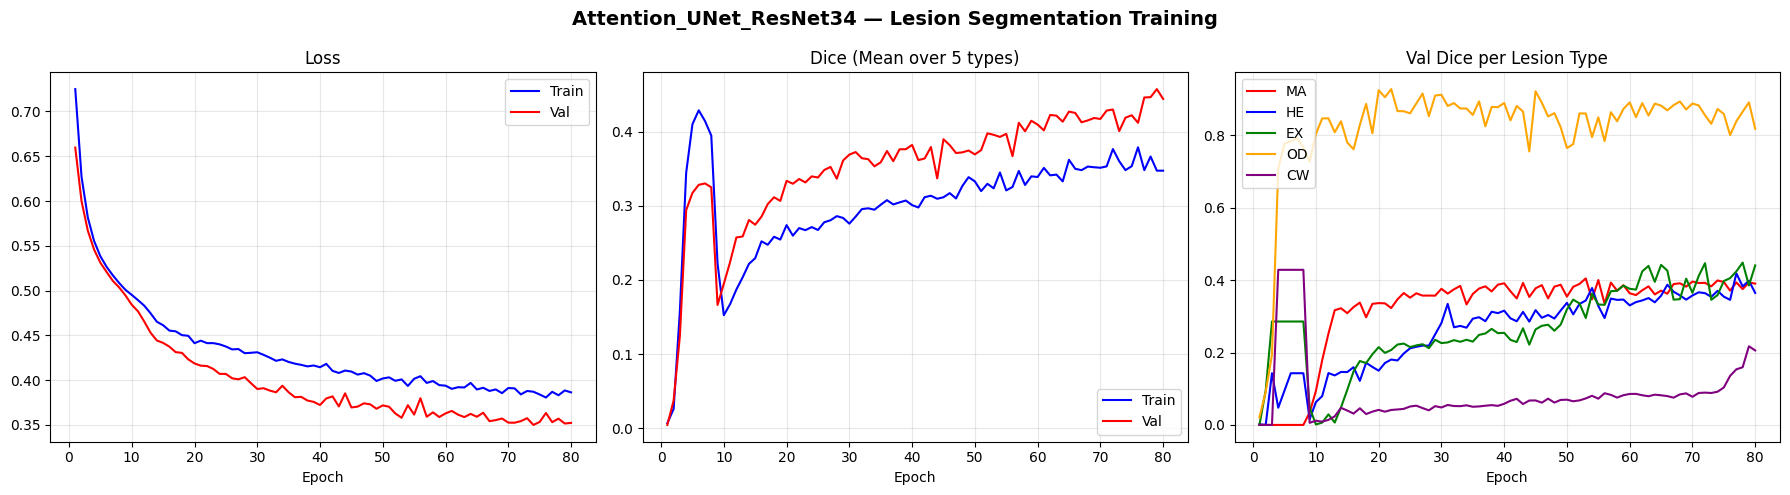

✅ Training curves saved


In [16]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{CFG["model_name"]} — Lesion Segmentation Training', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs, history['val_loss'], 'r-', label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mean Dice
axes[1].plot(epochs, history['train_dice_mean'], 'b-', label='Train')
axes[1].plot(epochs, history['val_dice_mean'], 'r-', label='Val')
axes[1].set_title('Dice (Mean over 5 types)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Per-Type Val Dice
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, lt in enumerate(LESION_TYPES):
    axes[2].plot(epochs, history[f'val_dice_{lt}'], color=colors[i], label=lt)
axes[2].set_title('Val Dice per Lesion Type')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, f'{CFG["model_name"]}_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')

## 10. Prediction Visualization

Shows original image + ground truth masks + predicted masks for each lesion type,
using distinct colors per type.

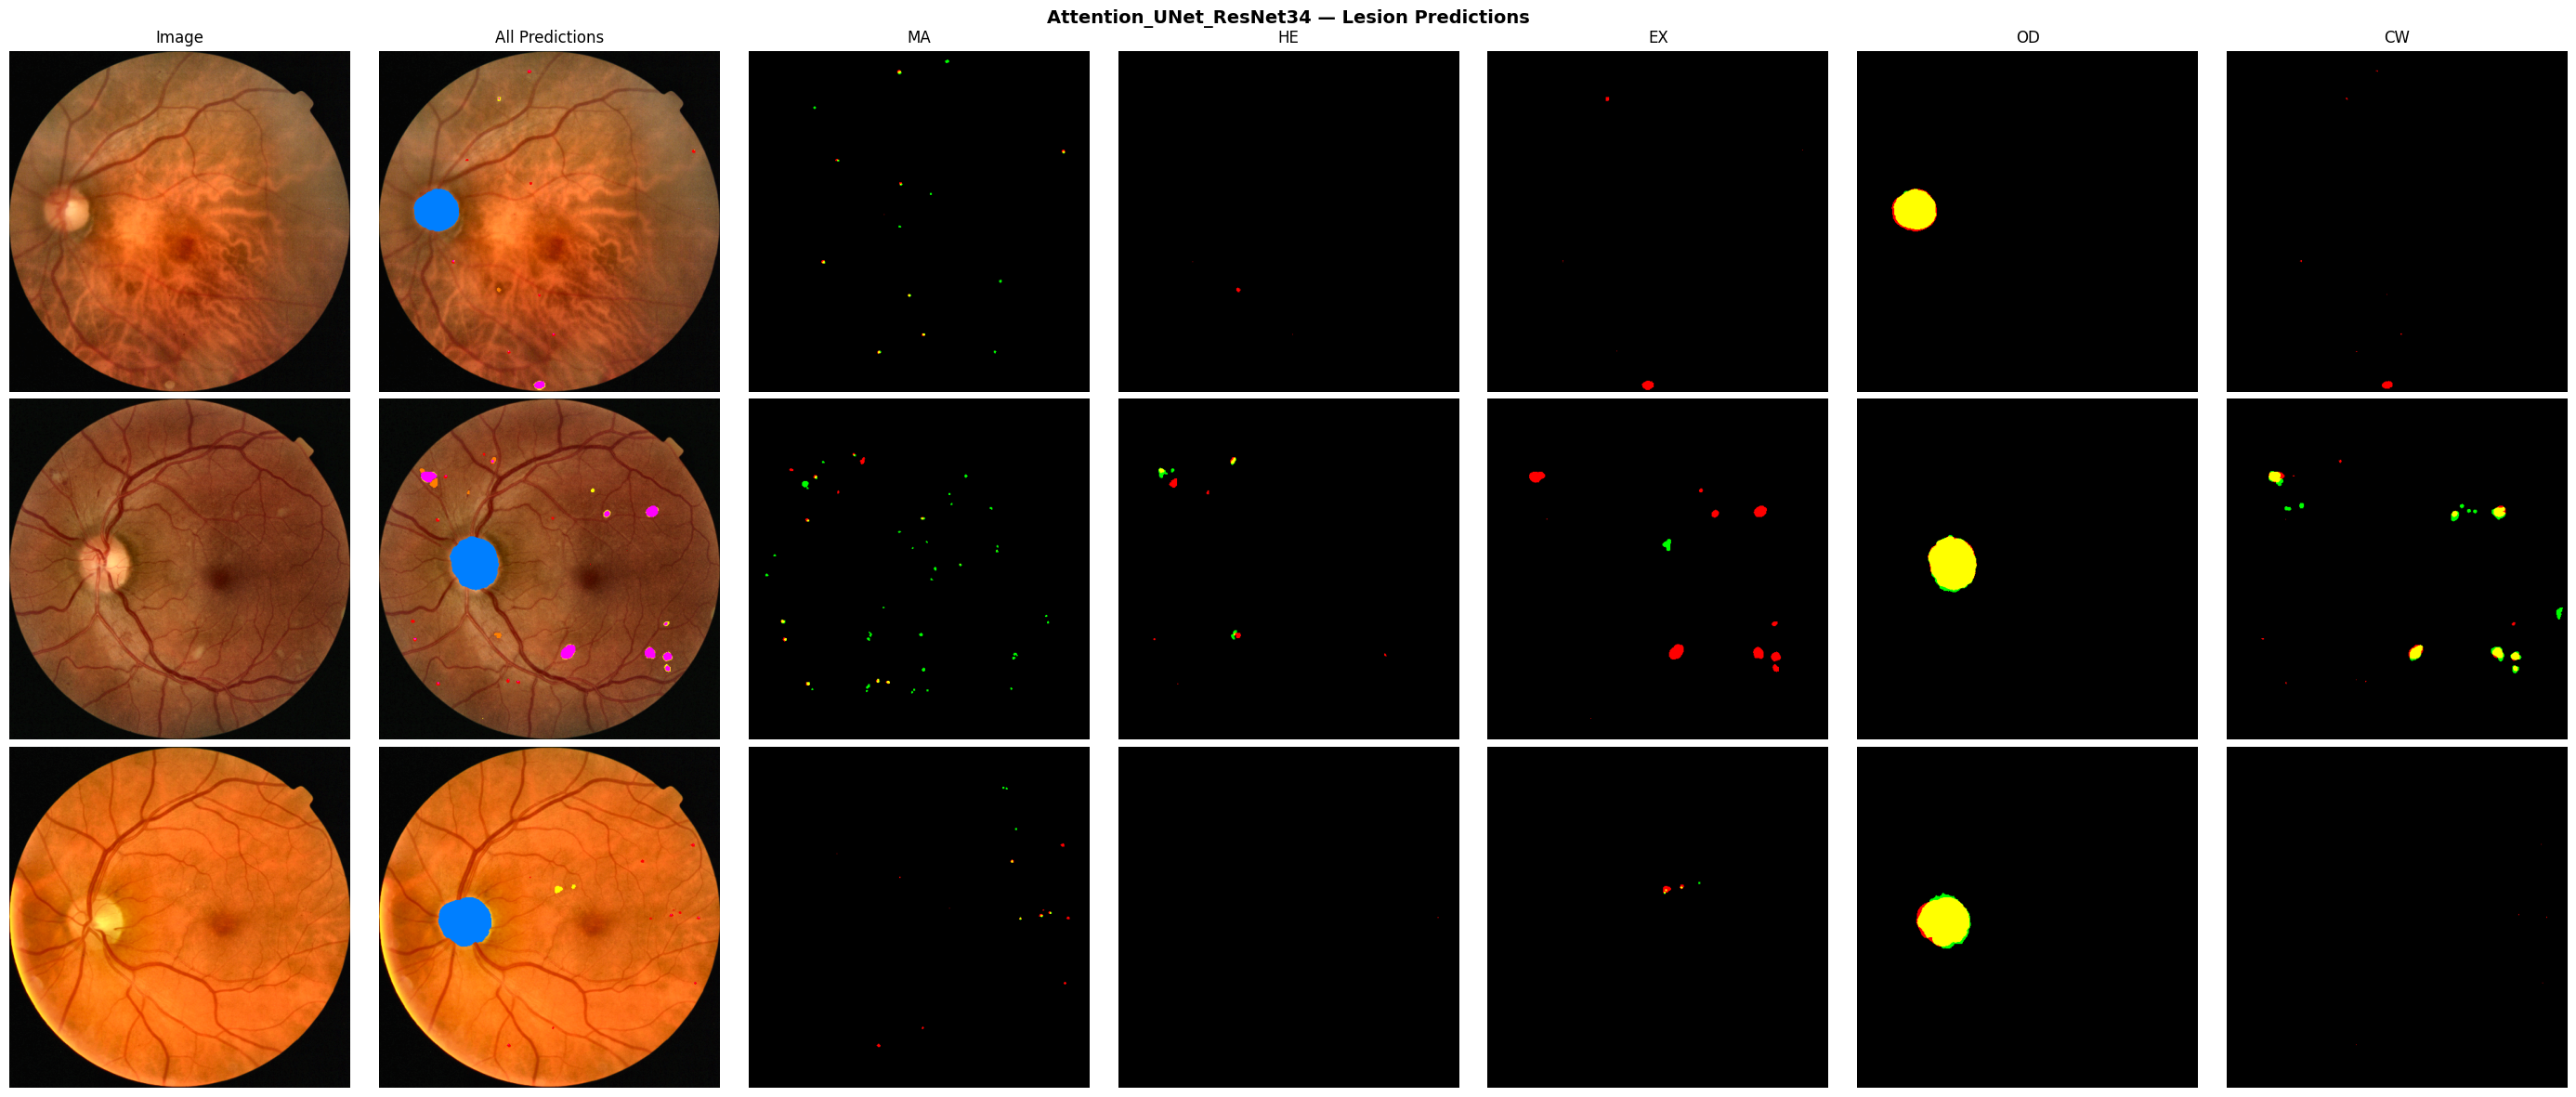

✅ Prediction visualization saved


In [17]:
def denormalize(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    tensor = tensor.cpu() * std + mean
    return torch.clamp(tensor, 0, 1).permute(1, 2, 0).numpy()

# Visualize predictions for a few test samples
num_samples = 3
lesion_colors = {
    'MA': [1, 0, 0],     # Red
    'HE': [1, 0.5, 0],   # Orange
    'EX': [1, 1, 0],     # Yellow
    'OD': [0, 0.5, 1],   # Blue
    'CW': [1, 0, 1],     # Magenta
}

fig, axes = plt.subplots(num_samples, 2 + NUM_LESION_CLASSES,
                         figsize=(4 * (2 + NUM_LESION_CLASSES), 4 * num_samples))
fig.suptitle(f'{CFG["model_name"]} — Lesion Predictions', fontsize=14, fontweight='bold')

shown = 0
model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        images_dev = images.to(device)
        preds = torch.sigmoid(model(images_dev)).cpu()

        for i in range(images.shape[0]):
            if shown >= num_samples:
                break

            img_np = denormalize(images[i])

            # Original image
            axes[shown, 0].imshow(img_np)
            axes[shown, 0].set_title('Image' if shown == 0 else '')
            axes[shown, 0].axis('off')

            # Overlay: all lesions combined
            overlay = img_np.copy()
            for ch, lt in enumerate(LESION_TYPES):
                gt_mask = masks[i, ch].numpy() > 0.5
                pred_mask = preds[i, ch].numpy() > CFG['threshold']
                color = lesion_colors[lt]
                overlay[pred_mask] = color
            axes[shown, 1].imshow(overlay)
            axes[shown, 1].set_title('All Predictions' if shown == 0 else '')
            axes[shown, 1].axis('off')

            # Per-type: GT (top half) vs Pred (bottom half)
            for ch, lt in enumerate(LESION_TYPES):
                gt = masks[i, ch].numpy()
                pr = (preds[i, ch].numpy() > CFG['threshold']).astype(float)
                combined = np.zeros((*gt.shape, 3))
                combined[:, :, 1] = gt    # Green = ground truth
                combined[:, :, 0] = pr    # Red = prediction
                both = (gt > 0.5) & (pr > 0.5)
                combined[both] = [1, 1, 0]  # Yellow = correct
                axes[shown, 2 + ch].imshow(combined)
                axes[shown, 2 + ch].set_title(lt if shown == 0 else '')
                axes[shown, 2 + ch].axis('off')

            shown += 1
        if shown >= num_samples:
            break

plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, f'{CFG["model_name"]}_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Prediction visualization saved')

In [18]:
print(f'\n🎉 Notebook complete!')
print(f'Model:     {CFG["model_name"]}')
print(f'Best Dice: {best_val_dice:.4f} (epoch {best_epoch})')
print(f'All outputs saved to: {SAVE_DIR}/')


🎉 Notebook complete!
Model:     Attention_UNet_ResNet34
Best Dice: 0.4571 (epoch 79)
All outputs saved to: lesion_results/Attention_UNet_ResNet34/


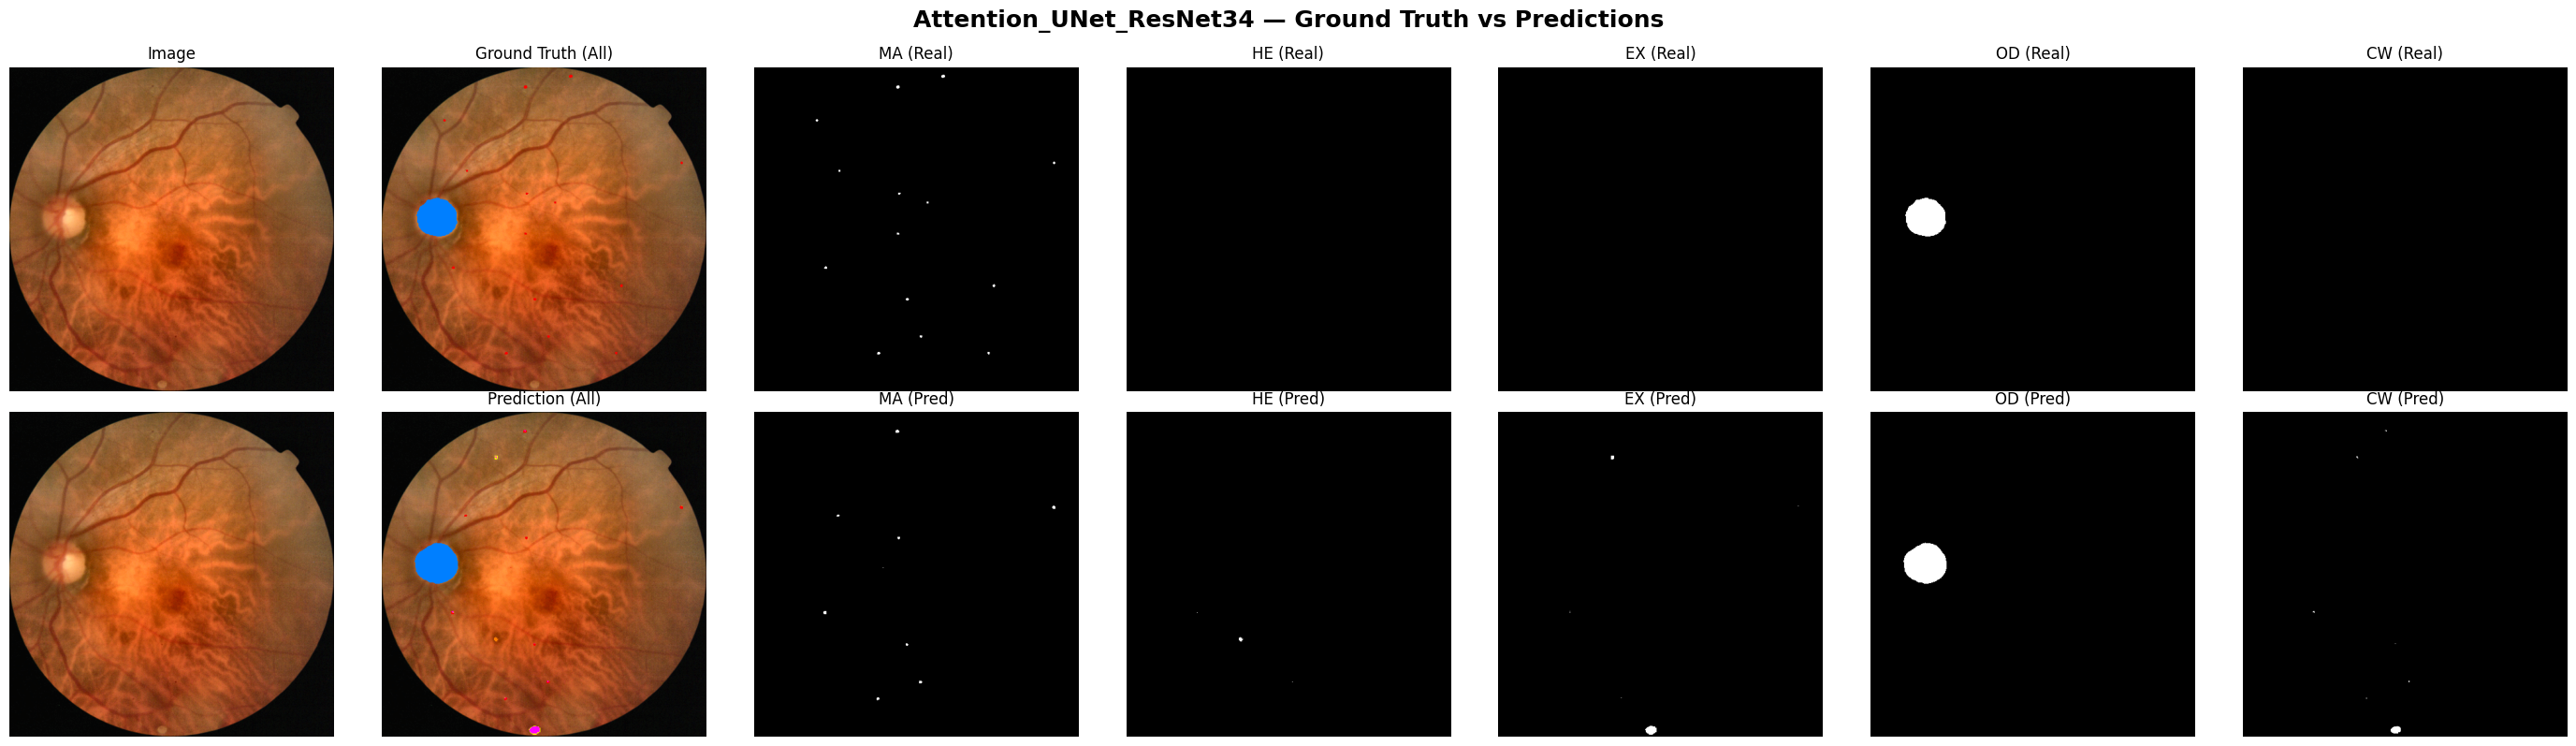

✅ Prediction visualization saved


In [21]:
def denormalize(tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    tensor = tensor.cpu() * std + mean
    return torch.clamp(tensor, 0, 1).permute(1, 2, 0).numpy()

# Visualize predictions for a few test samples
num_samples = 1
lesion_colors = {
    'MA': [1, 0, 0],     # Red
    'HE': [1, 0.5, 0],   # Orange
    'EX': [1, 1, 0],     # Yellow
    'OD': [0, 0.5, 1],   # Blue
    'CW': [1, 0, 1],     # Magenta
}

# We will plot 2 rows per sample: Top row = Ground Truth, Bottom row = Prediction
fig, axes = plt.subplots(num_samples * 2, 2 + NUM_LESION_CLASSES,
                         figsize=(4 * (2 + NUM_LESION_CLASSES), 4 * num_samples * 2))
fig.suptitle(f'{CFG["model_name"]} — Ground Truth vs Predictions', fontsize=18, fontweight='bold', y=0.99)

shown = 0
model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        images_dev = images.to(device)
        preds = torch.sigmoid(model(images_dev)).cpu()

        for i in range(images.shape[0]):
            if shown >= num_samples:
                break

            img_np = denormalize(images[i])
            r_gt = shown * 2       # Row for Ground Truth
            r_pr = shown * 2 + 1   # Row for Prediction

            # --- Column 0: Original Image ---
            axes[r_gt, 0].imshow(img_np)
            axes[r_gt, 0].set_title('Image' if shown == 0 else '')
            axes[r_gt, 0].axis('off')

            axes[r_pr, 0].imshow(img_np)
            axes[r_pr, 0].axis('off')

            # --- Column 1: All combined ---
            # 1. Ground Truth All
            gt_overlay = img_np.copy()
            for ch, lt in enumerate(LESION_TYPES):
                gt_mask = masks[i, ch].numpy() > 0.5
                gt_overlay[gt_mask] = lesion_colors[lt]
            axes[r_gt, 1].imshow(gt_overlay)
            axes[r_gt, 1].set_title('Ground Truth (All)' if shown == 0 else '')
            axes[r_gt, 1].axis('off')

            # 2. Prediction All
            pr_overlay = img_np.copy()
            for ch, lt in enumerate(LESION_TYPES):
                pred_mask = preds[i, ch].numpy() > CFG['threshold']
                pr_overlay[pred_mask] = lesion_colors[lt]
            axes[r_pr, 1].imshow(pr_overlay)
            axes[r_pr, 1].set_title('Prediction (All)' if shown == 0 else '')
            axes[r_pr, 1].axis('off')

            # --- Columns 2-6: Individual Lesions ---
            for ch, lt in enumerate(LESION_TYPES):
                gt_mask = masks[i, ch].numpy()
                pr_mask = (preds[i, ch].numpy() > CFG['threshold']).astype(float)

                # Plot purely black-and-white mask for Ground Truth
                axes[r_gt, 2 + ch].imshow(gt_mask, cmap='gray')
                axes[r_gt, 2 + ch].set_title(f'{lt} (Real)' if shown == 0 else '')
                axes[r_gt, 2 + ch].axis('off')

                # Plot purely black-and-white mask for Prediction
                axes[r_pr, 2 + ch].imshow(pr_mask, cmap='gray')
                axes[r_pr, 2 + ch].set_title(f'{lt} (Pred)' if shown == 0 else '')
                axes[r_pr, 2 + ch].axis('off')

            shown += 1

        if shown >= num_samples:
            break

plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, f'{CFG["model_name"]}_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Prediction visualization saved')


In [20]:
import shutil

folder_path = 'lesion_results/Attention_UNet_ResNet34'          # your folder name
zip_name = 'results_Attention_UNet_ResNet34'      # output zip name (without .zip)

shutil.make_archive(zip_name, 'zip', folder_path)

print(f"✅ Created: {zip_name}.zip")

✅ Created: results_Attention_UNet_ResNet34.zip
